# Day 08. Exercise 05
# Clustering

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

## 1. Preprocessing

1. Read the file [`regression.csv`](https://drive.google.com/file/d/1fzOPkuXoxLleOsvNVCT0m-LKxlid33ma/view?usp=sharing) to a dataframe.
2. Remove the `pageviews`, we will cluster the users only by the number of the commits and their average difference.

In [2]:
df = pd.read_csv('../data/regression.csv')
df = df.drop('pageviews', axis=1)
df.head()

,uid,num_commits,AVG(diff)
0,user_1,62,-64.400000
1,user_10,20,-74.800000
2,user_14,61,-159.000000
3,user_17,51,-61.600000
4,user_18,5,-5.666667


In [3]:
X = df[['num_commits', 'AVG(diff)']].values

## 2. KMeans

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters, use `random_state=21` and `n_clusters=3`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `n_clusters` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

In [4]:
k_range = range(2, 11)
sil_scores_k = []
best_k = None
best_score = -1

In [5]:
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=21, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    sil_scores_k.append(score)
    if score > best_score:
        best_score = score
        best_k = k
    print(f"k={k}: silhouette = {score:.4f}")

print(f"\nBest k = {best_k} (silhouette = {best_score:.4f})\n")

k=2: silhouette = 0.4179
k=3: silhouette = 0.4390
k=4: silhouette = 0.4397
k=5: silhouette = 0.4464
k=6: silhouette = 0.4457
k=7: silhouette = 0.4964
k=8: silhouette = 0.5078
k=9: silhouette = 0.4561
k=10: silhouette = 0.4254

Best k = 8 (silhouette = 0.5078)



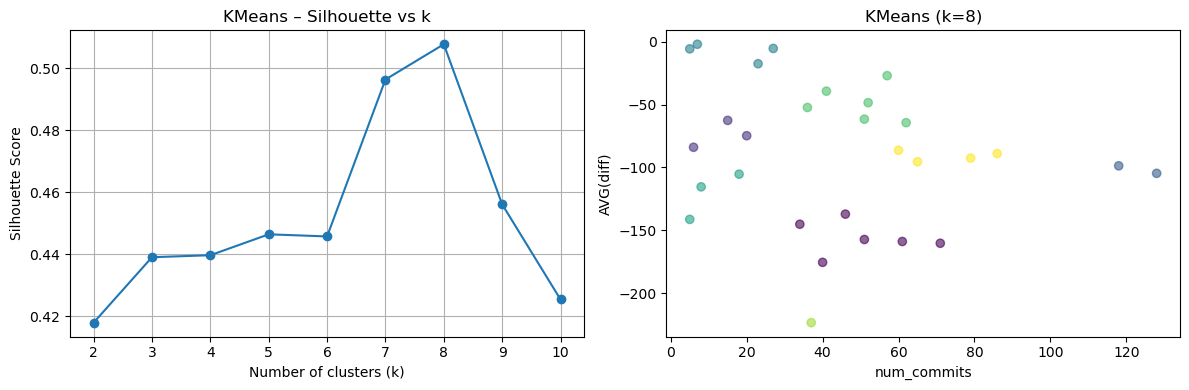

In [6]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(k_range, sil_scores_k, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('KMeans – Silhouette vs k')
plt.grid(True)

best_kmeans = KMeans(n_clusters=best_k, random_state=21, n_init=10)
labels_k = best_kmeans.fit_predict(X)
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=labels_k, cmap='viridis', alpha=0.6)
plt.xlabel('num_commits')
plt.ylabel('AVG(diff)')
plt.title(f'KMeans (k={best_k})')
plt.tight_layout()
plt.show()

## 3. DBSCAN

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters with `eps=20` and `min_samples=2`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `eps` and `min_samples` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

In [7]:
eps_range = [10, 15, 20, 22, 25, 30]
sil_scores_eps = []
best_eps = None
best_score_eps = -1
best_labels_eps = None

In [8]:
for eps in eps_range:
    db = DBSCAN(eps=eps, min_samples=1)
    labels = db.fit_predict(X)
    unique = set(labels)
    n_clusters = len(unique) - (1 if -1 in unique else 0)
    if n_clusters > 1:
        score = silhouette_score(X, labels)
        sil_scores_eps.append(score)
        if score > best_score_eps:
            best_score_eps = score
            best_eps = eps
            best_labels_eps = labels
        print(f"eps={eps}, min_samples=1 → silhouette = {score:.4f} (clusters={n_clusters})")
    else:
        sil_scores_eps.append(np.nan)
        print(f"eps={eps}, min_samples=1 → only {n_clusters} cluster(s)")

print(f"\nBest eps = {best_eps} (silhouette = {best_score_eps:.4f})")

eps=10, min_samples=1 → silhouette = 0.0928 (clusters=27)
eps=15, min_samples=1 → silhouette = 0.3970 (clusters=14)
eps=20, min_samples=1 → silhouette = 0.4322 (clusters=13)
eps=22, min_samples=1 → silhouette = 0.4871 (clusters=9)
eps=25, min_samples=1 → silhouette = 0.2997 (clusters=6)
eps=30, min_samples=1 → silhouette = 0.1988 (clusters=3)

Best eps = 22 (silhouette = 0.4871)


In [9]:
min_samples_range = [1, 2, 3, 4, 5]
sil_scores_ms = []
best_ms = None
best_score_ms = -1
best_labels_ms = None
for ms in min_samples_range:
    db = DBSCAN(eps=best_eps, min_samples=ms)
    labels = db.fit_predict(X)
    unique = set(labels)
    n_clusters = len(unique) - (1 if -1 in unique else 0)
    if n_clusters > 1:
        score = silhouette_score(X, labels)
        sil_scores_ms.append(score)
        if score > best_score_ms:
            best_score_ms = score
            best_ms = ms
            best_labels_ms = labels
        print(f"eps={best_eps}, min_samples={ms} → silhouette = {score:.4f} (clusters={n_clusters})")
    else:
        sil_scores_ms.append(np.nan)
        print(f"eps={best_eps}, min_samples={ms} → only {n_clusters} cluster(s)")

print(f"\nBest min_samples = {best_ms} (silhouette = {best_score_ms:.4f})")

eps=22, min_samples=1 → silhouette = 0.4871 (clusters=9)
eps=22, min_samples=2 → silhouette = 0.4794 (clusters=7)
eps=22, min_samples=3 → silhouette = 0.3596 (clusters=5)
eps=22, min_samples=4 → silhouette = 0.1456 (clusters=3)
eps=22, min_samples=5 → silhouette = 0.0580 (clusters=2)

Best min_samples = 1 (silhouette = 0.4871)


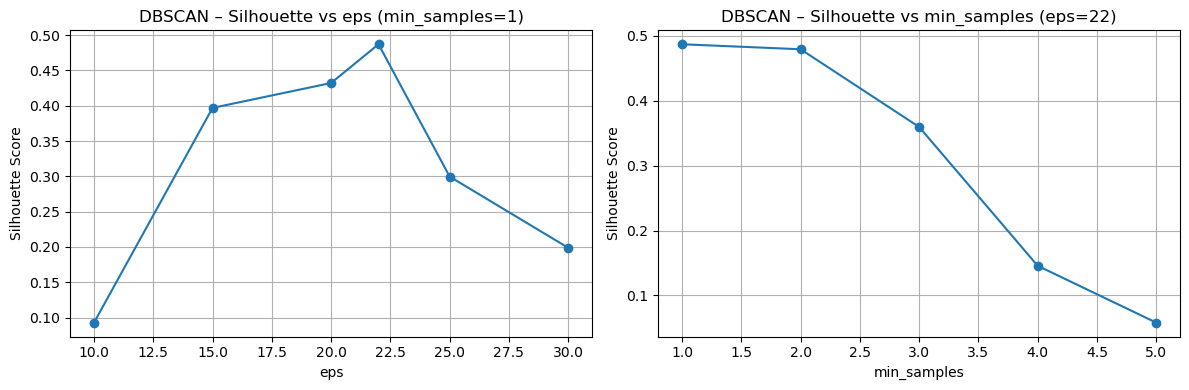

In [10]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(eps_range, sil_scores_eps, marker='o')
plt.xlabel('eps')
plt.ylabel('Silhouette Score')
plt.title('DBSCAN – Silhouette vs eps (min_samples=1)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(min_samples_range, sil_scores_ms, marker='o')
plt.xlabel('min_samples')
plt.ylabel('Silhouette Score')
plt.title(f'DBSCAN – Silhouette vs min_samples (eps={best_eps})')
plt.grid(True)
plt.tight_layout()
plt.show()

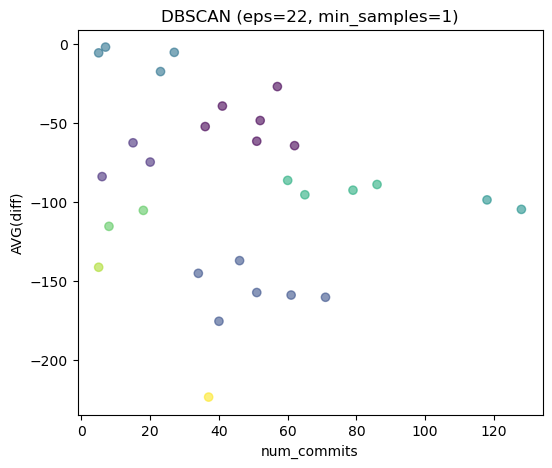

In [11]:
db_best = DBSCAN(eps=best_eps, min_samples=best_ms)
labels_db_best = db_best.fit_predict(X)
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels_db_best, cmap='viridis', alpha=0.6)
plt.xlabel('num_commits')
plt.ylabel('AVG(diff)')
plt.title(f'DBSCAN (eps={best_eps}, min_samples={best_ms})')
plt.show()

## 4. Hierarchical (AgglomerativeClustering)

1. Use this algorithm to create clusters with `n_clusters=5`.
2. Visualize the data on a `scatter plot`.
3. Try different values of `n_clusters` and see how your plot will change.
4. Calculate the `silhouette_score`.
5. Visualize the `dendrogram`.

In [12]:
n_range = range(2, 11)
sil_scores_agg = []
best_n = None
best_score_agg = -1

In [13]:
for n in n_range:
    agg = AgglomerativeClustering(n_clusters=n)
    labels = agg.fit_predict(X)
    score = silhouette_score(X, labels)
    sil_scores_agg.append(score)
    if score > best_score_agg:
        best_score_agg = score
        best_n = n
    print(f"n_clusters={n}: silhouette = {score:.4f}")

print(f"\nBest n_clusters = {best_n} (silhouette = {best_score_agg:.4f})")

n_clusters=2: silhouette = 0.3590
n_clusters=3: silhouette = 0.3390
n_clusters=4: silhouette = 0.4448
n_clusters=5: silhouette = 0.4638
n_clusters=6: silhouette = 0.4527
n_clusters=7: silhouette = 0.4866
n_clusters=8: silhouette = 0.5078
n_clusters=9: silhouette = 0.4758
n_clusters=10: silhouette = 0.4312

Best n_clusters = 8 (silhouette = 0.5078)


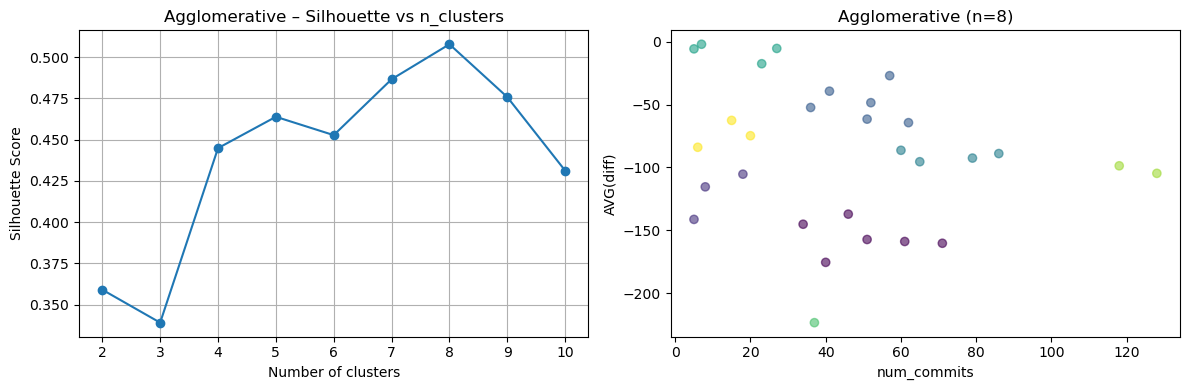

In [14]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(n_range, sil_scores_agg, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Agglomerative – Silhouette vs n_clusters')
plt.grid(True)

best_agg = AgglomerativeClustering(n_clusters=best_n)
labels_agg = best_agg.fit_predict(X)
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=labels_agg, cmap='viridis', alpha=0.6)
plt.xlabel('num_commits')
plt.ylabel('AVG(diff)')
plt.title(f'Agglomerative (n={best_n})')
plt.tight_layout()
plt.show()

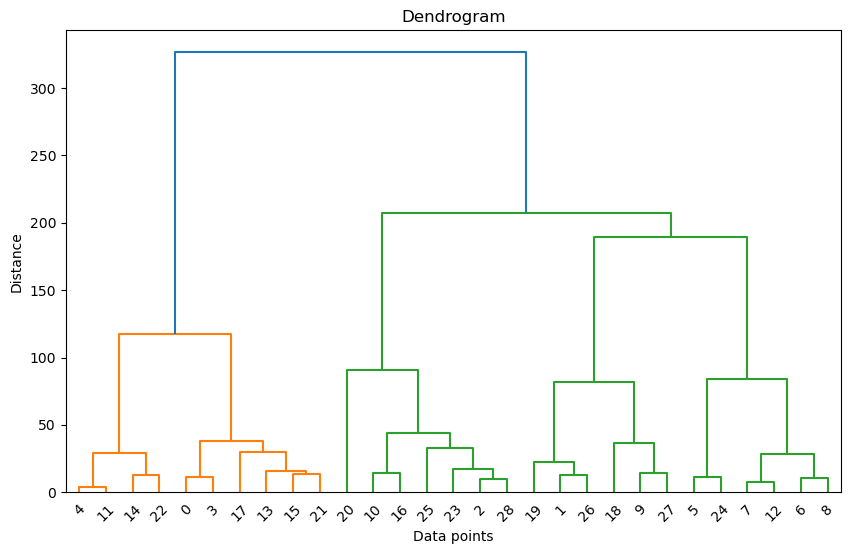

In [15]:
plt.figure(figsize=(10, 6))
linkage_matrix = linkage(X, method='ward')
dendrogram(linkage_matrix, truncate_mode='level', p=10)
plt.title('Dendrogram')
plt.xlabel('Data points')
plt.ylabel('Distance')
plt.show()

## 5. Function

Write a function that:
1. Takes as arguments: model class of clustering, its parameters, the name of the parameter for optimization, the range of the parameter values to try.
2. Tries different values from the given parameter range and calculates the `silhouette_score` for each value from the range.
3. Finds out the best value for the parameter in the range.
4. Returns two subplots:


- - the first shows how the `silhouette_score` changes depending on the value of the parameter,
- - the second visualizes the data on a `scatter plot` using the clustering model with the best value of the parameter.

In [16]:
def optimize_clustering(model_class, param_name, param_range, X, **fixed_params):
    sil_scores = []
    best_score = -1
    best_param = None
    best_labels = None
    for val in param_range:
        params = {param_name: val, **fixed_params}
        model = model_class(**params)
        labels = model.fit_predict(X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters <= 1:
            sil_scores.append(np.nan)
            continue
        score = silhouette_score(X, labels)
        sil_scores.append(score)
        if score > best_score:
            best_score = score
            best_param = val
            best_labels = labels

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(param_range, sil_scores, marker='o')
    plt.xlabel(param_name)
    plt.ylabel('Silhouette Score')
    plt.title(f'Silhouette vs {param_name}')
    plt.grid(True)
    plt.subplot(1, 2, 2)
    plt.scatter(X[:, 0], X[:, 1], c=best_labels, cmap='viridis', alpha=0.6)
    plt.xlabel('num_commits')
    plt.ylabel('AVG(diff)')
    plt.title(f'Best {model_class.__name__} (param={best_param}, score={best_score:.4f})')
    plt.tight_layout()
    plt.show()
    return best_param, best_labels, sil_scores

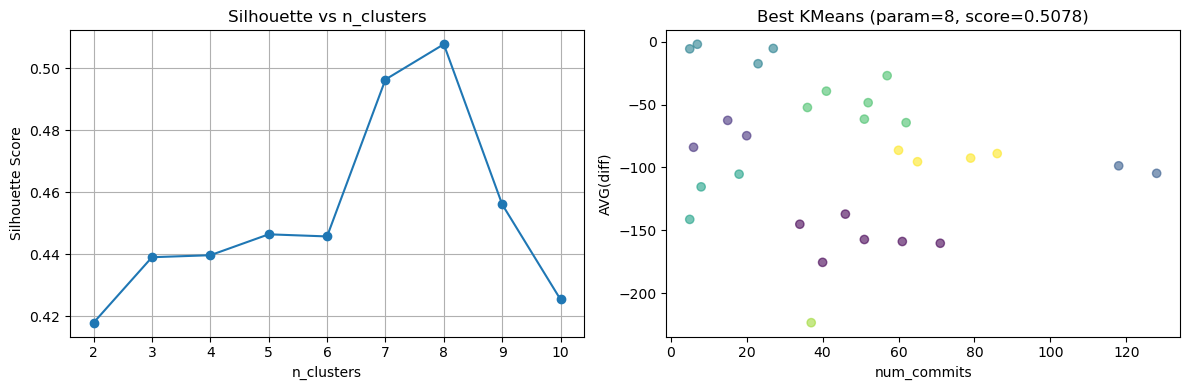

Best n_clusters: 8, best silhouette: 0.5078


In [17]:
best_param, best_labels, sil_scores = optimize_clustering(KMeans, 'n_clusters', range(2, 11), X, random_state=21, n_init=10)
print(f"Best n_clusters: {best_param}, best silhouette: {max(sil_scores):.4f}")

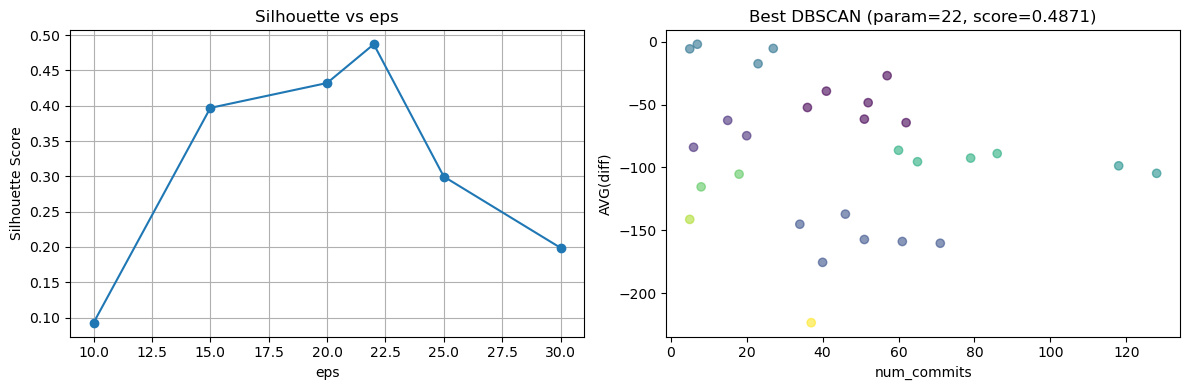

Best n_clusters: 22, best silhouette: 0.4871


In [18]:
best_param, best_labels, sil_scores= optimize_clustering(DBSCAN, 'eps', [10, 15, 20, 22, 25, 30], X, min_samples=1)
print(f"Best n_clusters: {best_param}, best silhouette: {max(sil_scores):.4f}")

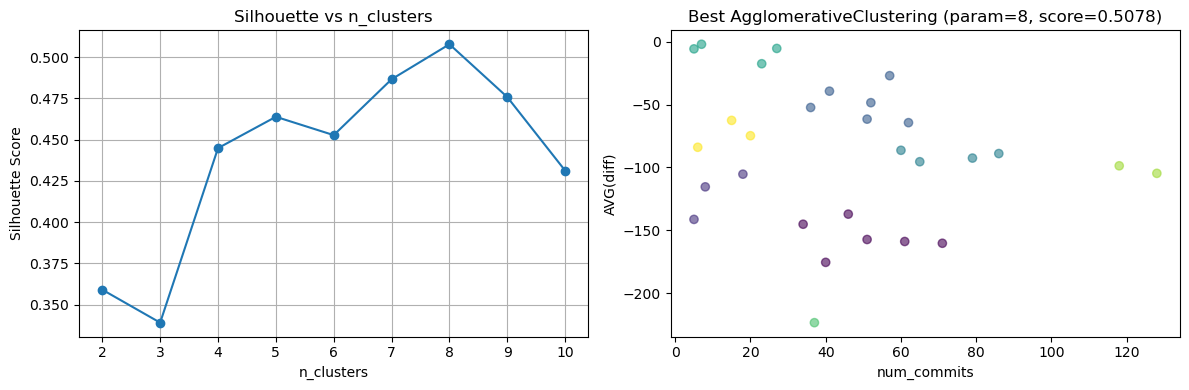

Best n_clusters: 8, best silhouette: 0.5078


In [19]:
best_param, best_labels, sil_scores = optimize_clustering(AgglomerativeClustering, 'n_clusters', range(2, 11), X)
print(f"Best n_clusters: {best_param}, best silhouette: {max(sil_scores):.4f}")